In [1]:
import modules.data as d
import modules.model as m
import modules.train as t
import modules.utils as u

import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path

In [2]:
# dataset dir
datasets = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')

# get device
device, generator = u.Devices().auto_set_device()

# get data
brca = d.Data(
    # datasets
    tcga_project = 'TCGA-BRCA',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',

    # dirs
    tcga_dir = datasets / 'tcga',
    relation_filepath = datasets / 'other/relation_ohe.csv',
    
    # col, filter
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Metastatic']},
    max_subset=120,
)

*** Device() ***
device = cuda:2

**** Data() ****
log0_method      log1p            str
class_weights    (6,)             Tensor (cuda:2)
gene_counts      (4383, 567)      DataFrame
metadata         (567, 3)         DataFrame
relation         (75939, 19)      DataFrame
node_id_map      4383             dict
masks            305              list
X                (567, 4383, 1)   Tensor (cuda:2)
y                (567, 6)         Tensor (cuda:2)
y_labels         6                list
num_samples      567              int
num_nodes        4383             int
num_features     1                int
num_labels       6                int
num_masks        305              int



In [3]:
# # run experiment
# brca_GCNc = t.Experiment(
#     data=brca,
#     generator=generator,

#     model_class=m.GCNClassifier,
#     model_kwargs={
#         'in_features':brca.num_features,
#         'out_features':brca.num_labels,
#         'relation':brca.relation,
#         'num_nodes':brca.num_nodes,
#         'gcn_kwargs':{'end_fn':nn.LeakyReLU()}
#     },

#     training_class=t.ClassifierTrainingModule,
#     training_kwargs={
#         'loss_fn':nn.CrossEntropyLoss(brca.class_weights),
#         'optimizer':torch.optim.Adam,
#         'num_epochs':100,
#         'report_metrics':['tot_loss', 'accuracy'],
#     },

#     num_trials=10,
#     comment='experiment_class_test'
# )



---

In [4]:
# run experiment
brca_MLPc = t.Experiment(
    data=brca,
    generator=generator,

    model_class=m.MLPClassifier,
    model_kwargs={
        'in_features':brca.num_nodes,
        'out_features':brca.num_labels,
        'flatten':True,
    },

    training_class=t.ClassifierTrainingModule,
    training_kwargs={
        'loss_fn':nn.CrossEntropyLoss(brca.class_weights),
        'optimizer':torch.optim.Adam,
        'num_epochs':30,
        'report_metrics':['tot_loss', 'accuracy'],
    },

    num_trials=3,
    comment='experiment_class_test'
)



100%|██████████| 30/30 [00:00<00:00, 45.76it/s, Epoch 29      Train: tot_loss=0.3513    accuracy=0.9924        Val: tot_loss=2.6102    accuracy=0.8588] 


Test	 tot_loss=9.6500    accuracy=0.8353



100%|██████████| 30/30 [00:00<00:00, 55.00it/s, Epoch 29      Train: tot_loss=0.4083    accuracy=0.9924        Val: tot_loss=2.1269    accuracy=0.8706]


Test	 tot_loss=6.5693    accuracy=0.8824



100%|██████████| 30/30 [00:00<00:00, 69.81it/s, Epoch 29      Train: tot_loss=0.3986    accuracy=0.9874        Val: tot_loss=2.0323    accuracy=0.9176]


Test	 tot_loss=8.5111    accuracy=0.8471



---

(0.8549019607843138, 0.0244901882290133, <Figure size 1600x900 with 1 Axes>)

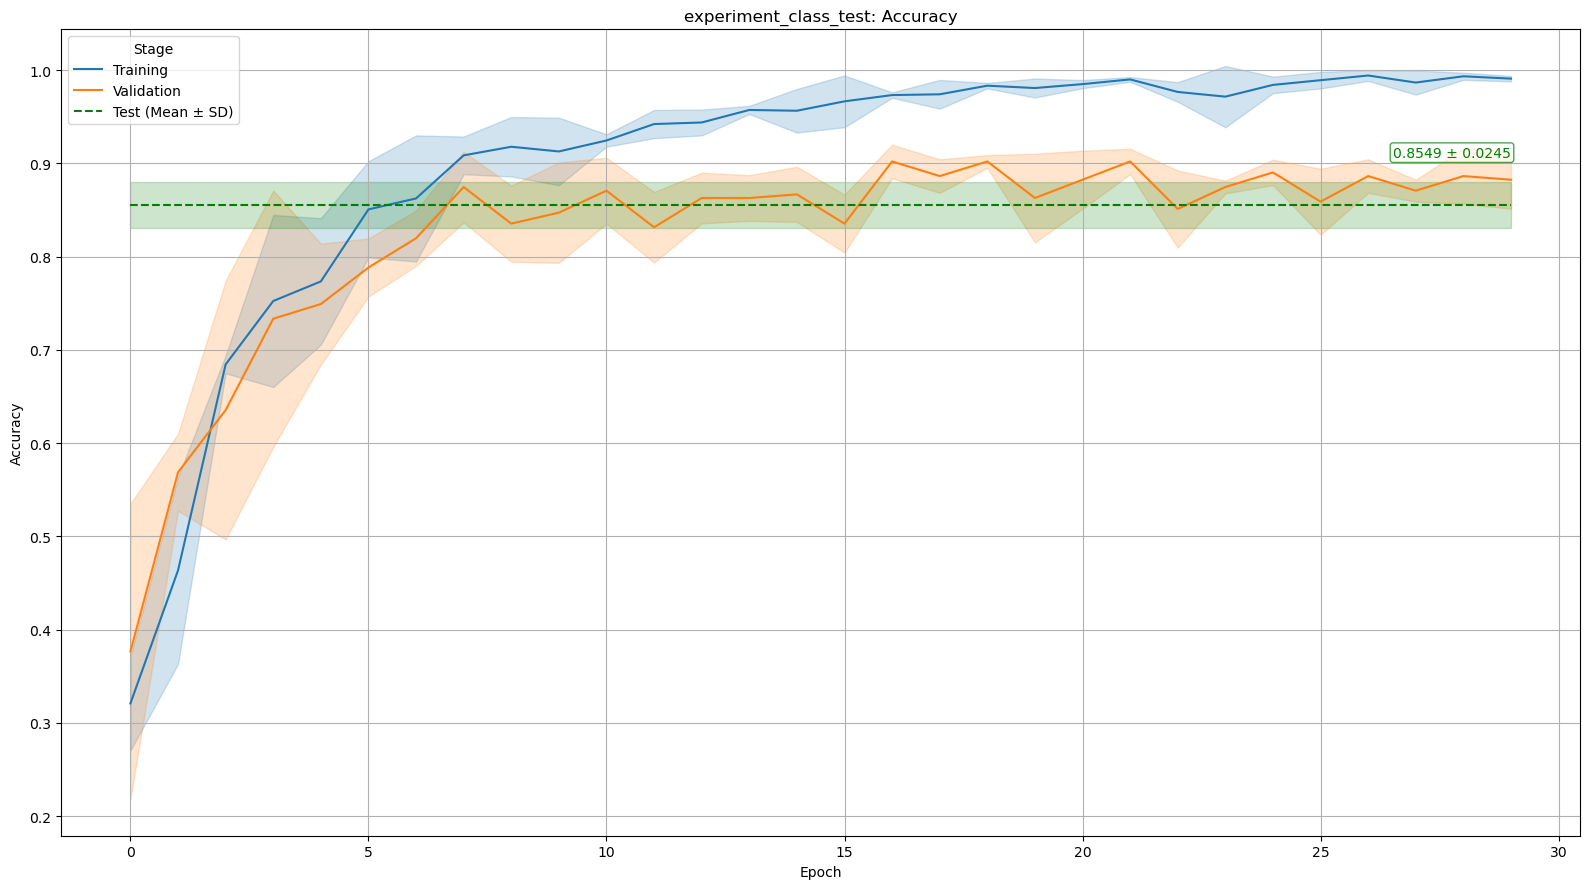

In [6]:
brca_MLPc.results('accuracy')

---